In [11]:
import numpy as np
from scipy.fft import rfft, rfftfreq
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1) Generate synthetic audio dataset: two classes with different dominant frequencies
fs = 2000  # sampling rate
duration = 1.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)


def make_signal(freq, noise_level=0.3):
    x = np.sin(2 * np.pi * freq * t) + noise_level * np.random.randn(len(t))
    return x


n_samples = 200
X_audio = []
y_audio = []

for _ in range(n_samples // 2):
    X_audio.append(make_signal(200))  # class 0: 200 Hz tone
    y_audio.append(0)
for _ in range(n_samples // 2):
    X_audio.append(make_signal(600))  # class 1: 600 Hz tone
    y_audio.append(1)

X_audio = np.array(X_audio)
y_audio = np.array(y_audio)

# 2) FFT-based feature extraction
# Use only first K frequency bins (low frequency part)
K = 100


def fft_features(x):
    Xf = rfft(x)  # real FFT
    mag = np.abs(Xf)  # magnitude spectrum
    mag = mag[:K]  # keep first K bins
    mag = np.log1p(mag)  # log scaling for stability
    return mag


X_feats = np.vstack([fft_features(x) for x in X_audio])

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_feats, y_audio, test_size=0.25, random_state=42, stratify=y_audio
)

# 4) Scale + train simple classifier
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train_s, y_train)

print("Train acc:", clf.score(X_train_s, y_train))
print("Test acc:", clf.score(X_test_s, y_test))


Train acc: 0.9733333333333334
Test acc: 0.52


In [8]:
X_feats.shape

(200, 100)

In [2]:
import numpy as np
from scipy.fft import fft2, fftshift
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# 1) Generate synthetic image data
# Class 0: vertical stripes, Class 1: horizontal stripes
def make_vertical_stripes(size=32, period=4):
    img = np.zeros((size, size))
    for x in range(size):
        img[:, x] = (x // period) % 2
    return img


def make_horizontal_stripes(size=32, period=4):
    img = np.zeros((size, size))
    for y in range(size):
        img[y, :] = (y // period) % 2
    return img


n_samples = 200
imgs = []
labels = []

for _ in range(n_samples // 2):
    imgs.append(make_vertical_stripes() + 0.2 * np.random.randn(32, 32))
    labels.append(0)

for _ in range(n_samples // 2):
    imgs.append(make_horizontal_stripes() + 0.2 * np.random.randn(32, 32))
    labels.append(1)

imgs = np.array(imgs)
labels = np.array(labels)

# 2) 2D FFT feature extraction
# Take small central patch of magnitude spectrum as feature
patch = 8


def fft2_features(img):
    F = fft2(img)
    F_shift = fftshift(F)
    mag = np.abs(F_shift)
    c = img.shape[0] // 2
    patch_mag = mag[c - patch // 2 : c + patch // 2, c - patch // 2 : c + patch // 2]
    feats = np.log1p(patch_mag).flatten()
    return feats


X_img_feats = np.vstack([fft2_features(im) for im in imgs])

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_img_feats, labels, test_size=0.25, random_state=42, stratify=labels
)

# 4) Scale + train classifier
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)

print("Train acc:", clf.score(X_train_s, y_train))
print("Test acc:", clf.score(X_test_s, y_test))


Train acc: 1.0
Test acc: 1.0


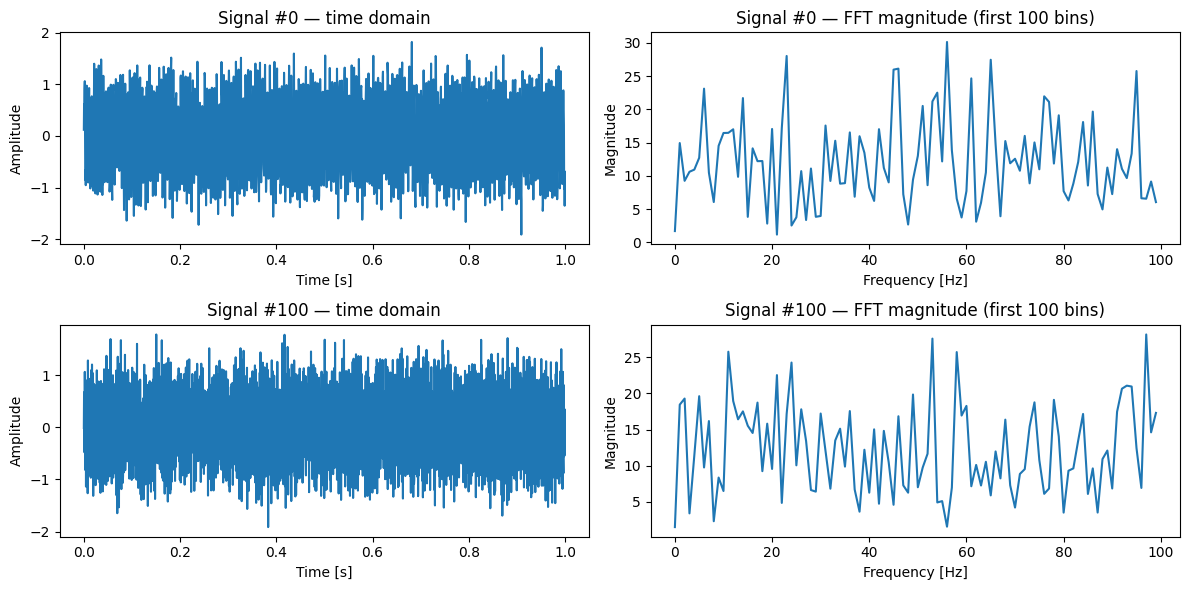

In [12]:
import matplotlib.pyplot as plt

# choose two example signals (one from each class if available)
idxs = [0, n_samples // 2] if 'n_samples' in globals() else [0, 1]

fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 3 * len(idxs)))
if len(idxs) == 1:
    axes = axes.reshape(1, -1)

for i, idx in enumerate(idxs):
    x = X_audio[idx]
    axes[i, 0].plot(t, x)
    axes[i, 0].set_title(f"Signal #{idx} — time domain")
    axes[i, 0].set_xlabel("Time [s]")
    axes[i, 0].set_ylabel("Amplitude")

    Xf = rfft(x)
    freqs = rfftfreq(x.size, 1 / fs)
    mag = np.abs(Xf)

    axes[i, 1].plot(freqs[:K], mag[:K])
    axes[i, 1].set_title(f"Signal #{idx} — FFT magnitude (first {K} bins)")
    axes[i, 1].set_xlabel("Frequency [Hz]")
    axes[i, 1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()